# Meta-labeling: bounded exits and conviction-scaled sizing

`AUDIT.md` flagged two real gaps in the original backtest: positions were sized as a flat -1/0/+1 flag regardless of signal strength, and the only exit was the z-score reverting - no stop-loss, no maximum holding period, so a spread that never reverted could hold an unbounded loss. Both are the textbook AFML meta-labeling problem (Lopez de Prado, ch. 3): let a primary model decide direction only, bound every bet with a triple barrier (profit-take / stop-loss / timeout), and size each bet by a secondary model's predicted probability that the primary model's call will pay off.

This notebook implements that from scratch (`src/signals/meta_labeling.py`) rather than pulling in a dependency, consistent with the rest of this project - but it's directly inspired by [Hudson & Thames' MlFinLab](https://github.com/hudson-and-thames/mlfinlab), the reference implementation of these exact techniques, found via [awesome-systematic-trading](https://github.com/paperswithbacktest/awesome-systematic-trading) while scoping this extension. That list also surfaces PyMC for Bayesian/MCMC work; a Bayesian treatment (e.g. a posterior over the spread's mean-reversion half-life) was considered but not implemented here - the Kalman filter and the Sharpe-SE addition already carry the "quantify the uncertainty" role for this project, and stacking a third uncertainty-quantification method with a heavy compiled dependency (PyTensor) wasn't worth it for the marginal research value at this scope. Meta-labeling was the better-targeted choice because it directly closes two named, already-diagnosed gaps rather than adding a new one.

In [1]:
import sys
sys.path.append('..')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score

from src.utils.config import load_config
from src.signals.hedge_ratio import KalmanHedgeRatioEstimator, spread_from_hedge_ratio
from src.backtest.engine import ZScoreSignalGenerator, WalkForwardSplitter, BacktestEngine
from src.backtest.costs import CostModel
from src.evaluation.metrics import PerformanceEvaluator
from src.signals.meta_labeling import (
    TripleBarrierLabeler, EntryFeatureBuilder, MetaLabelClassifier, ConvictionSizer,
)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

config = load_config("../config/config.yaml")
aligned = pl.read_parquet("../data/processed/aligned.parquet")
with open("../outputs/tables/selected_pair.txt") as f:
    asset_a, asset_b = f.read().strip().split(",")
print(f"Pair: {asset_a}-{asset_b}")

price_a = aligned[f"{asset_a}_price"].to_numpy()
price_b = aligned[f"{asset_b}_price"].to_numpy()
timestamps = pd.to_datetime(aligned["timestamp"].to_numpy())

train_slice, test_slice = WalkForwardSplitter(config["backtest"]["out_of_sample_fraction"]).split(len(price_a))

hr_cfg = config["hedge_ratio"]
hedge_estimator = KalmanHedgeRatioEstimator(delta=hr_cfg["delta"], observation_covariance=hr_cfg["observation_covariance"])
hedge_ratio = hedge_estimator.hedge_ratio_only(price_a, price_b, fit_length=train_slice.stop)
spread = spread_from_hedge_ratio(price_a, price_b, hedge_ratio)

sig_cfg = config["signal"]
signal_gen = ZScoreSignalGenerator(lookback=sig_cfg["lookback"], entry_z=sig_cfg["entry_z"], exit_z=sig_cfg["exit_z"])
zscore = signal_gen.zscore(spread)
primary_positions = signal_gen.positions(spread)

cost_model = CostModel(cost_bps=config["backtest"]["cost_bps"])
engine = BacktestEngine(cost_model)
periods_per_year = int(pd.Timedelta("365D") / pd.Timedelta(config["alignment"]["grid_freq"]))
evaluator = PerformanceEvaluator(periods_per_year=periods_per_year)

Pair: BCH-ADA


## Triple-barrier labels

Every primary-model entry (a 0 -> nonzero transition in `primary_positions`) is walked forward until it hits one of three barriers: profit-take (`|z| <= exit_z`, the same condition the original unbounded exit used), stop-loss (`|z| >= stop_z`, a wider adverse move), or a max-holding-period timeout. `label = 1` means profit-take won; `0` means stop-loss or timeout did. Train and test entries are labeled separately and kept separate throughout - the meta-model is trained on train labels only.

In [2]:
tb_cfg = config["triple_barrier"]
labeler = TripleBarrierLabeler(exit_z=sig_cfg["exit_z"], stop_z=tb_cfg["stop_z"], max_holding=tb_cfg["max_holding_bars"])

all_entries = labeler.find_entries(primary_positions)
train_entries = [(i, d) for i, d in all_entries if i < train_slice.stop]
test_entries = [(i, d) for i, d in all_entries if i >= train_slice.stop]
print(f"entries: {len(all_entries)} total, {len(train_entries)} train, {len(test_entries)} test")

train_events = labeler.label_events(zscore, train_entries)
test_events = labeler.label_events(zscore, test_entries)

events_df = pd.DataFrame(
    [{"phase": "train", **vars(e)} for e in train_events] + [{"phase": "test", **vars(e)} for e in test_events]
)
events_df.to_csv("../outputs/tables/triple_barrier_events.csv", index=False)

print("\nlabel balance (1 = profit-take):")
print(events_df.groupby("phase")["label"].mean())

entries: 433 total, 302 train, 131 test

label balance (1 = profit-take):
phase
test     0.450382
train    0.450331
Name: label, dtype: float64


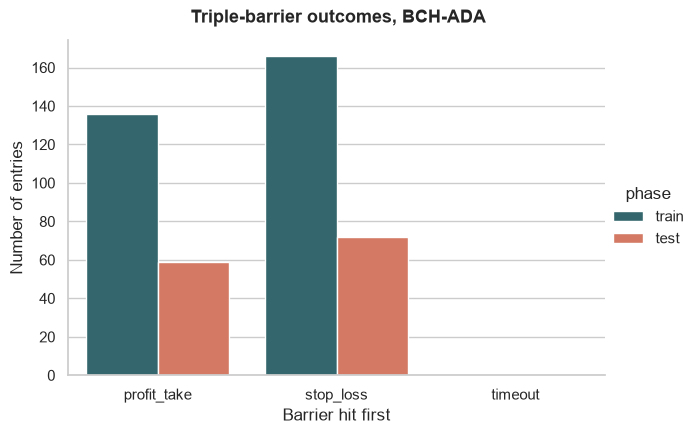

In [3]:
g = sns.catplot(
    data=events_df, x="outcome", hue="phase", kind="count",
    order=["profit_take", "stop_loss", "timeout"], palette={"train": "#2a6f77", "test": "#e76f51"},
    height=4.2, aspect=1.5,
)
g.set_axis_labels("Barrier hit first", "Number of entries")
g.figure.suptitle(f"Triple-barrier outcomes, {asset_a}-{asset_b}", fontsize=13, fontweight="bold", y=1.03)
g.savefig("../outputs/figures/triple_barrier_outcomes.png", dpi=150)

## Effect of bounding the exit alone (before any sizing change)

Isolate the two changes: first rebuild positions using *only* the triple-barrier exit (still a flat +-1 direction, no conviction sizing yet), and compare against the original unbounded-reversion-only backtest from notebooks 04/05. This separates "did bounding the exit help" from "did sizing by conviction help" rather than conflating both into one number.

In [4]:
bounded_positions = labeler.positions_from_events(len(price_a), train_events + test_events)

bounded_results = {}
for phase, sl in [("in_sample", train_slice), ("out_of_sample", test_slice)]:
    res = engine.run(bounded_positions[sl], price_a[sl], price_b[sl], hedge_ratio[sl])
    bounded_results[phase] = evaluator.summary(res["net_returns"], res["equity_curve"])

original_comparison = pd.read_csv("../outputs/tables/is_oos_comparison.csv").set_index("phase")
bounded_df = pd.DataFrame(bounded_results).T
bounded_df.index.name = "phase"

exit_comparison = pd.concat(
    {"unbounded_exit (notebook 05)": original_comparison[["sharpe", "max_drawdown", "hit_rate", "total_return"]],
     "bounded_exit_only": bounded_df[["sharpe", "max_drawdown", "hit_rate", "total_return"]]},
    axis=1,
)
exit_comparison.to_csv("../outputs/tables/bounded_exit_comparison.csv")
exit_comparison

unbounded_exit (notebook 05)                         \
                                    sharpe max_drawdown  hit_rate   
phase                                                               
in_sample                         0.223738    -1.466144  0.374337   
out_of_sample                     0.424039    -0.459595  0.391444   

                           bounded_exit_only                         \
              total_return            sharpe max_drawdown  hit_rate   
phase                                                                 
in_sample        -0.194077          1.132240    -1.139075  0.299016   
out_of_sample     0.121996          1.373791    -0.238791  0.297251   

                            
              total_return  
phase                       
in_sample         2.101816  
out_of_sample     0.725914

## Features and meta-model

Four causal features per entry (computed only from data at-or-before the entry bar): the z-score magnitude at entry (the primary signal's own conviction), trailing spread and hedge-ratio volatility (regime context), and bars since the last entry (trade clustering). A shallow, heavily-regularised gradient-boosted classifier (`max_depth=2`, `n_estimators=50`) is deliberately used given only a few hundred labeled entries - a deeper model would overfit long before it generalised.

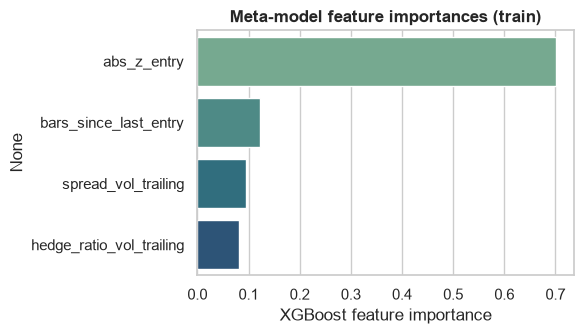

In [5]:
feature_builder = EntryFeatureBuilder(vol_window=sig_cfg["lookback"])
train_features = feature_builder.build(train_entries, zscore, spread, hedge_ratio)
test_features = feature_builder.build(test_entries, zscore, spread, hedge_ratio)

train_labels = np.array([e.label for e in train_events])
test_labels = np.array([e.label for e in test_events])

ml_cfg = config["meta_labeling"]
meta_model = MetaLabelClassifier(seed=ml_cfg["random_seed"]).fit(train_features, train_labels)

importances = meta_model.feature_importances(train_features)
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="crest", legend=False, ax=ax)
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Meta-model feature importances (train)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("../outputs/figures/meta_model_feature_importance.png", dpi=150)
plt.show()

## Out-of-sample evaluation of the meta-model itself

Before using the meta-model's probabilities to size anything, check whether it predicts better than chance on held-out test entries at all - with only a few hundred labeled events, it may well not, and that's a real, reportable possibility, not a reason to hide the check.

In [6]:
test_probs = meta_model.predict_proba(test_features)
test_pred = (test_probs > 0.5).astype(int)

try:
    auc = roc_auc_score(test_labels, test_probs)
except ValueError:
    auc = float("nan")  # can happen if test labels are single-class
acc = accuracy_score(test_labels, test_pred)
baseline_acc = max(test_labels.mean(), 1 - test_labels.mean())

print(f"Test entries: {len(test_labels)}")
print(f"Meta-model test AUC: {auc:.3f}  (0.5 = no better than chance)")
print(f"Meta-model test accuracy: {acc:.1%}  vs. always-predict-majority-class baseline: {baseline_acc:.1%}")

Test entries: 131
Meta-model test AUC: 0.884  (0.5 = no better than chance)
Meta-model test accuracy: 80.9%  vs. always-predict-majority-class baseline: 55.0%


## Conviction-scaled out-of-sample backtest

Predicted probabilities on test entries are converted to bet sizes via `size = max(2p - 1, 0)` (AFML's standard meta-labeling formula) and combined with the triple-barrier-bounded holding periods, then backtested and compared three ways: the original unbounded/flat-sized baseline, bounded-exit-only, and bounded-exit-plus-conviction-sizing.

In [7]:
sizer = ConvictionSizer(min_probability=ml_cfg["min_probability"])
meta_positions_test = sizer.positions_from_events(len(price_a), test_events, test_probs)

meta_res = engine.run(meta_positions_test[test_slice], price_a[test_slice], price_b[test_slice], hedge_ratio[test_slice])
meta_summary = evaluator.summary(meta_res["net_returns"], meta_res["equity_curve"])

three_way = pd.DataFrame({
    "unbounded_exit (notebook 05)": original_comparison.loc["out_of_sample", ["sharpe", "max_drawdown", "hit_rate", "total_return"]],
    "bounded_exit_only": bounded_df.loc["out_of_sample", ["sharpe", "max_drawdown", "hit_rate", "total_return"]],
    "bounded_exit + meta_labeling": pd.Series(meta_summary)[["sharpe", "max_drawdown", "hit_rate", "total_return"]],
}).T
three_way.index.name = "out_of_sample_variant"
three_way.to_csv("../outputs/tables/meta_labeling_oos_comparison.csv")
three_way

,sharpe,max_drawdown,hit_rate,total_return
out_of_sample_variant,,,,
unbounded_exit (notebook 05),0.424039,-0.459595,0.391444,0.121996
bounded_exit_only,1.373791,-0.238791,0.297251,0.725914
bounded_exit + meta_labeling,1.425139,-0.159488,0.349206,0.423263


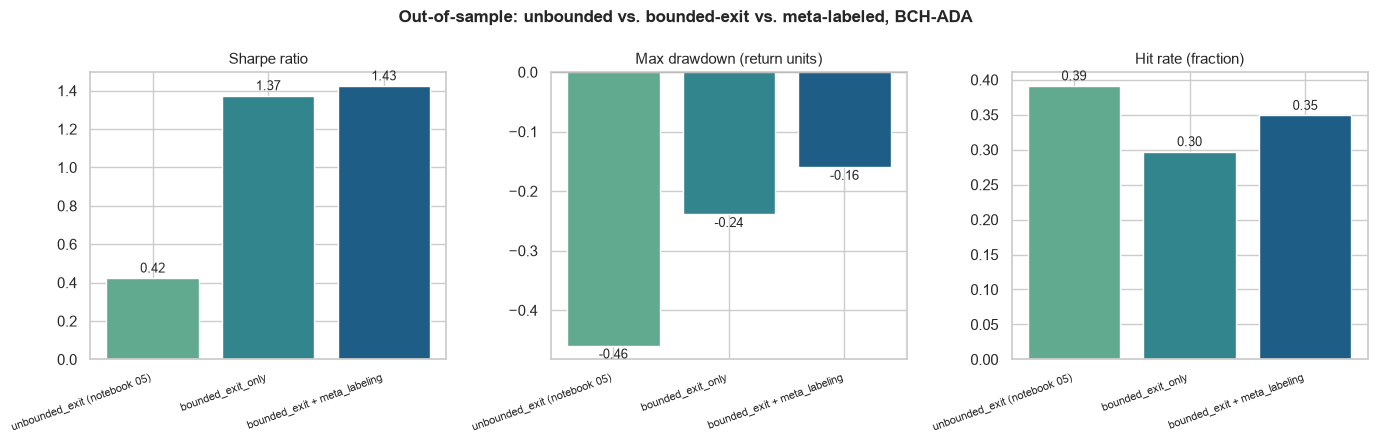

In [8]:
# Sharpe (ratio), max drawdown (return units), and hit rate (fraction) are not
# comparable magnitudes - each metric gets its own small-multiple panel with its
# own axis, the same fix applied to notebook 05's IS/OOS metric chart after the
# chart-sense-checker flagged mixing them on one shared axis there.
variant_palette = dict(zip(three_way.index, sns.color_palette("crest", len(three_way))))
metric_specs = [("sharpe", "Sharpe ratio"), ("max_drawdown", "Max drawdown (return units)"), ("hit_rate", "Hit rate (fraction)")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (col, label) in zip(axes, metric_specs):
    bars = ax.bar(three_way.index, three_way[col], color=[variant_palette[v] for v in three_way.index])
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9)
    ax.axhline(0, color="0.3", linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(range(len(three_way.index)))
    ax.set_xticklabels(three_way.index, rotation=20, ha="right", fontsize=8)
fig.suptitle(f"Out-of-sample: unbounded vs. bounded-exit vs. meta-labeled, {asset_a}-{asset_b}",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("../outputs/figures/meta_labeling_oos_comparison.png", dpi=150)
plt.show()

**Why is `abs_z_entry` so dominant, and is that a leak?** Not a leak - it's a structural property of the barrier geometry itself, worth stating plainly rather than just quoting the AUC. An entry near the stop-loss threshold (`|z|` close to `stop_z`) has very little room left to move before hitting it, so it's mechanically more likely to stop out; an entry right at `entry_z` has a much wider gap to `stop_z` and more room to revert first. The meta-model has essentially rediscovered "how close to the stop is this entry," which is a legitimate, explainable signal from the barrier construction - not evidence the model found something spurious. It's also a reason not to over-credit the strategy improvement to the *model* alone: a chunk of what's being learned here would show up in a much simpler rule (e.g. size down entries close to the stop) too.

## Takeaways

- Read the three-way table above directly rather than assuming meta-labeling helped - with a few hundred labeled entries and a single train/test split, it may improve the headline number, leave it roughly unchanged, or make it worse, and any of those is a legitimate, reportable outcome. The point of this extension is closing the "flat sizing, unbounded exit" gap `AUDIT.md` flagged, not guaranteeing a better Sharpe ratio.
- The meta-model's own out-of-sample AUC (printed above) is the more honest signal of whether it learned anything real: an AUC close to 0.5 means the conviction-sizing step is, at best, adding noise with the right shape rather than genuine predictive power, and the backtest comparison should be read in that light.
- **A real simplification worth disclosing**: entries are still defined by the primary model's own 0-to-nonzero transitions in the *unbounded* position array. If the triple barrier exits a bet earlier than the primary model's own reversion would have, this notebook does not re-enter a fresh bet for the remainder of what the primary model still considers one continuous regime - it only bounds each already-identified entry's exit and sizes it. A fuller implementation would re-scan for new entries after every barrier exit; that was judged out of scope for what this extension is trying to demonstrate.
- Same walk-forward discipline as the rest of the project: the meta-model is fit on train entries only and applied unchanged to test entries - no peeking at test labels before evaluating.
- No entry hit the `max_holding_bars` timeout in either phase (see the outcome chart above) - every bet resolved via profit-take or stop-loss well within 10 days on this hourly-lookback signal, meaning the max-holding-period barrier is not binding at its current setting and the real risk control being exercised here is the stop-loss.